In [3]:
import pandas as pd
import numpy as np
from prophet import Prophet

import matplotlib.pyplot as plt
%matplotlib inline
import datetime
from datetime import timedelta
from kmodes.kmodes import KModes


In [4]:
df_datos = pd.read_csv('entries_all.csv')

In [5]:
df_datos = df_datos.drop(columns='Unnamed: 0')

In [6]:
df_datos = df_datos.drop(columns='Entrada')

In [7]:
#df_datos = df_datos.drop(columns='Autonomia')

In [8]:
df_datos.Profesion = df_datos.Profesion.fillna('Otros')

In [9]:
df_datos = df_datos[df_datos['Continente'].notna()]

In [10]:
df_datos.reset_index(inplace=True, drop=True)

In [11]:
df_datos.Fecha = pd.to_datetime(df_datos['Fecha'])

In [12]:
df_datos['Año'] = df_datos['Fecha'].dt.year
df_datos['Mes'] = df_datos['Fecha'].dt.month
df_datos['Dia'] = df_datos['Fecha'].dt.day

In [13]:
df_datos = df_datos[(df_datos['Sexo'].notna())&(df_datos['Sexo']!='D')]

In [14]:
#Cluster España
spain = df_datos[df_datos['Pais']=='España']

In [15]:
spain['Autonomia'] = spain['Autonomia'].fillna('Otros')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13352\1473269454.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spain['Autonomia'] = spain['Autonomia'].fillna('Otros')


In [16]:
spain.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1668685 entries, 0 to 3288627
Data columns (total 14 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   Fecha       1668685 non-null  datetime64[ns]
 1   Sexo        1668685 non-null  object        
 2   Edad        1668685 non-null  int64         
 3   Continente  1668685 non-null  object        
 4   Pais        1668685 non-null  object        
 5   Autonomia   1668685 non-null  object        
 6   Medio       1668685 non-null  object        
 7   Motivo      1668685 non-null  object        
 8   Camino      1668685 non-null  object        
 9   Origen      1668685 non-null  object        
 10  Profesion   1668685 non-null  object        
 11  Año         1668685 non-null  int64         
 12  Mes         1668685 non-null  int64         
 13  Dia         1668685 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(9)
memory usage: 191.0+ MB


In [17]:
spain.head()

,Fecha,Sexo,Edad,Continente,Pais,Autonomia,Medio,Motivo,Camino,Origen,Profesion,Año,Mes,Dia
0,2010-01-01,M,58,Europa,España,Cantabria,Bicicleta,Religioso,Norte-Camino de,Resto Cantabria,Jubilados,2010,1,1
1,2010-01-01,M,62,Europa,España,La Rioja,Pie,Religioso,Frances-Camino de,Sarria,Jubilados,2010,1,1
2,2010-01-01,M,54,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Liberales,2010,1,1
3,2010-01-01,F,44,Europa,España,Comunidad Valenciana,Pie,Religioso,Frances-Camino de,Ponferrada,Tecnicos,2010,1,1
8,2010-01-01,M,43,Europa,España,Castilla la Mancha,Pie,Religioso,Frances-Camino de,Sarria,Empleados,2010,1,1


In [ ]:
num_clusters = 8
km = KModes(n_clusters=num_clusters, init='Huang', n_init=10, verbose=1)
clusters = km.fit_predict(spain)
print(km.cluster_centroids_)

In [ ]:
spain['Clusters'] = clusters

In [ ]:
spain.Clusters.value_counts()

In [ ]:
spain['Cluster'] = clusters
colors = ['r', 'g', 'b', 'y']
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(num_clusters):
    cluster_data = spain[spain['Cluster'] == i]
    pd.plotting.parallel_coordinates(cluster_data.drop('Cluster', axis=1), 'Cluster', color=colors[i], ax=ax)
plt.legend(labels=['Cluster {}'.format(i) for i in range(num_clusters)])
plt.title('K-Modes Clustering Results')
plt.show()

In [18]:
# Eliminar columnas innecesarias
spain = spain.drop(["Medio", "Motivo"], axis=1)

# Convertir variables categóricas en variables numéricas con one-hot encoding
spain = pd.get_dummies(spain, columns=["Sexo","Profesion"])

In [19]:
# Normalizar las variables numéricas
# Definir las columnas numéricas

numerical_cols = ['Edad', 'Mes', 'Dia']

# Normalizar las variables numéricas
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
spain[numerical_cols] = scaler.fit_transform(spain[numerical_cols])

In [20]:
spain.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1668685 entries, 0 to 3288627
Data columns (total 30 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   Fecha                    1668685 non-null  datetime64[ns]
 1   Edad                     1668685 non-null  float64       
 2   Continente               1668685 non-null  object        
 3   Pais                     1668685 non-null  object        
 4   Autonomia                1668685 non-null  object        
 5   Camino                   1668685 non-null  object        
 6   Origen                   1668685 non-null  object        
 7   Año                      1668685 non-null  int64         
 8   Mes                      1668685 non-null  float64       
 9   Dia                      1668685 non-null  float64       
 10  Sexo_F                   1668685 non-null  uint8         
 11  Sexo_M                   1668685 non-null  uint8         
 12  

In [21]:
cols_cluster = spain.columns.to_list()
cols_cluster

['Fecha',
 'Edad',
 'Continente',
 'Pais',
 'Autonomia',
 'Camino',
 'Origen',
 'Año',
 'Mes',
 'Dia',
 'Sexo_F',
 'Sexo_M',
 'Profesion_Agricultores',
 'Profesion_Amas de Casa',
 'Profesion_Artistas',
 'Profesion_Deportistas',
 'Profesion_Directivos',
 'Profesion_Empleados',
 'Profesion_Estudiantes',
 'Profesion_Funcionarios',
 'Profesion_Jubilados',
 'Profesion_Liberales',
 'Profesion_Marinos',
 'Profesion_Obreros',
 'Profesion_Otros',
 'Profesion_Parados',
 'Profesion_Profesores',
 'Profesion_Religiosas/os',
 'Profesion_Sacerdotes',
 'Profesion_Tecnicos']

In [22]:
# Importar librerías necesarias
from sklearn.cluster import KMeans

cols_cluster = ['Edad', 'Mes', 'Dia', 'Sexo_F', 'Sexo_M',
 'Profesion_Agricultores',
 'Profesion_Amas de Casa',
 'Profesion_Artistas',
 'Profesion_Deportistas',
 'Profesion_Directivos',
 'Profesion_Empleados',
 'Profesion_Estudiantes',
 'Profesion_Funcionarios',
 'Profesion_Jubilados',
 'Profesion_Liberales',
 'Profesion_Marinos',
 'Profesion_Obreros',
 'Profesion_Otros',
 'Profesion_Parados',
 'Profesion_Profesores',
 'Profesion_Religiosas/os',
 'Profesion_Sacerdotes',
 'Profesion_Tecnicos']


# Crear el objeto KMeans y especificar el número de clusters (K)
kmeans = KMeans(n_clusters=3, random_state=0)

# Entrenar el modelo con los datos
kmeans.fit(spain[cols_cluster])

# Obtener las etiquetas de los clusters para cada registro
labels = kmeans.labels_

# Añadir las etiquetas al dataframe original
spain['Cluster'] = labels


C:\Users\Usuario\AppData\Roaming\Python\Python39\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [23]:
spain.Cluster

0          1
1          1
2          1
3          1
8          1
          ..
3288619    2
3288621    2
3288625    2
3288626    2
3288627    2
Name: Cluster, Length: 1668685, dtype: int32

In [24]:
inertia = kmeans.inertia_
inertia

5140235.204394847

In [31]:
spain['Edad_desescalada'] = scaler.inverse_transform(spain[numerical_cols])[:, 0]

spain['Año_desescalada'] = scaler.inverse_transform(spain[numerical_cols])[:, 1]

spain['Mes_desescalada'] = scaler.inverse_transform(spain[numerical_cols])[:, 2]

#spain['EDia_desescalada'] = scaler.inverse_transform(spain[numerical_cols])[:, 3]



In [32]:
# Identificar las columnas correspondientes a la variable Sexo
sexo_cols = [col for col in spain.columns if col.startswith("Sexo_")]

# Definir función para deshacer el One-Hot Encoding de la variable Sexo
def deshacer_onehot_sexo(row):
    if row["Sexo_F"] == 1:
        return "Femenino"
    elif row["Sexo_M"] == 1:
        return "Masculino"
    else:
        return None

# Aplicar función a las columnas correspondientes a la variable Sexo
spain["Sexo"] = spain.apply(deshacer_onehot_sexo, axis=1)

# Eliminar las columnas correspondientes al One-Hot Encoding de la variable Sexo
spain.drop(columns=sexo_cols, inplace=True)

KeyError: 'Sexo_F'

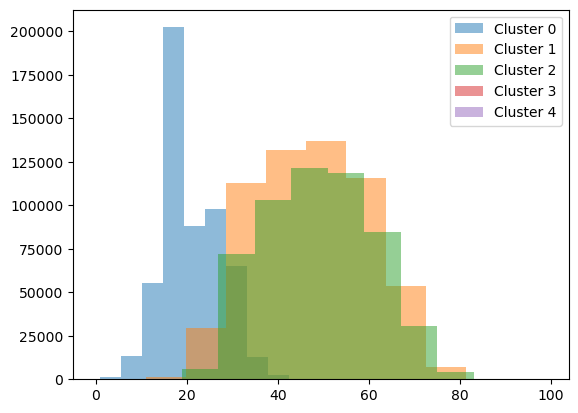

In [33]:
import matplotlib.pyplot as plt

# Crear un histograma por cluster
for i in range(5):
    plt.hist(spain.loc[spain['Cluster'] == i, 'Edad_desescalada'], alpha=0.5, label='Cluster {}'.format(i))
plt.legend()
plt.show()


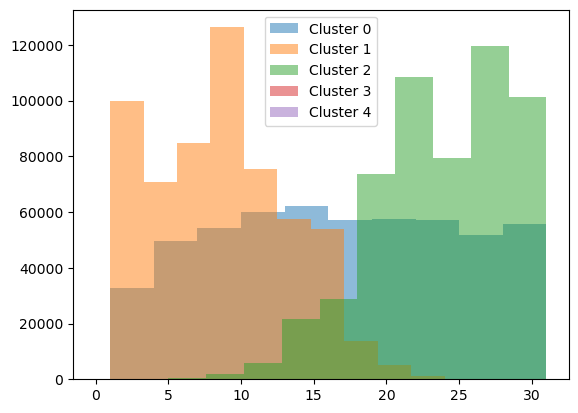

In [34]:
# Crear un histograma por cluster
for i in range(5):
    plt.hist(spain.loc[spain['Cluster'] == i, 'Mes_desescalada'], alpha=0.5, label='Cluster {}'.format(i))
plt.legend()
plt.show()

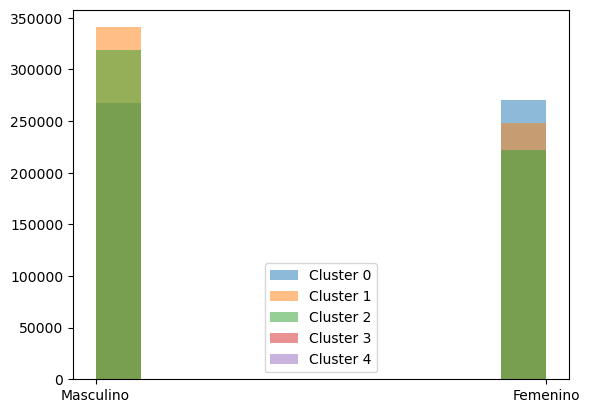

In [35]:
# Crear un histograma por cluster
for i in range(5):
    plt.hist(spain.loc[spain['Cluster'] == i, 'Sexo'], alpha=0.5, label='Cluster {}'.format(i))
plt.legend()
plt.show()